# Imports

In [41]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load in data

In [42]:
path = kagglehub.dataset_download("alistairking/weather-long-term-time-series-forecasting")

In [43]:
df = pd.read_csv(f"{path}\\cleaned_weather.csv")
df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


# Data cleaning and engineering

## Check for missing values

In [44]:
df.isnull().sum()

date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64

No missing values

## Check types

In [45]:
df.dtypes

date         object
p           float64
T           float64
Tpot        float64
Tdew        float64
rh          float64
VPmax       float64
VPact       float64
VPdef       float64
sh          float64
H2OC        float64
rho         float64
wv          float64
max. wv     float64
wd          float64
rain        float64
raining     float64
SWDR        float64
PAR         float64
max. PAR    float64
Tlog        float64
dtype: object

`date` feature is of type object, we convert it to datetime.

In [46]:
df["date"] = pd.to_datetime(df["date"])
df.dtypes

date        datetime64[ns]
p                  float64
T                  float64
Tpot               float64
Tdew               float64
rh                 float64
VPmax              float64
VPact              float64
VPdef              float64
sh                 float64
H2OC               float64
rho                float64
wv                 float64
max. wv            float64
wd                 float64
rain               float64
raining            float64
SWDR               float64
PAR                float64
max. PAR           float64
Tlog               float64
dtype: object

## Trigonometric features based on time

In [47]:
df["hour_sin"] = np.sin(2 * np.pi * df["date"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["date"].dt.hour / 24)
df["month_sin"] = np.sin(2 * np.pi * df["date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["date"].dt.month / 12)

df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rain,raining,SWDR,PAR,max. PAR,Tlog,hour_sin,hour_cos,month_sin,month_cos
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,0.0,0.0,0.0,0.0,0.0,11.45,0.0,1.0,0.5,0.866025
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,0.0,0.0,0.0,0.0,0.0,11.51,0.0,1.0,0.5,0.866025
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,0.0,0.0,0.0,0.0,0.0,11.60,0.0,1.0,0.5,0.866025
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,0.0,0.0,0.0,0.0,0.0,11.70,0.0,1.0,0.5,0.866025
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,0.0,0.0,0.0,0.0,0.0,11.81,0.0,1.0,0.5,0.866025


# Train Val Test split

## Split

In [48]:
n = len(df)
eda_df = df[0:int(n*0.7)]
df = df.drop(columns=["date"])

train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

## Scaling

In [49]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

## Creating windows

In [50]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window = 72
X_train, y_train = create_sequences(train_scaled, window)
X_val, y_val = create_sequences(val_scaled, window)
X_test, y_test = create_sequences(test_scaled, window)

# Exploratory Data Analysis

## Basic statistics

In [55]:
eda_df.describe()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rain,raining,SWDR,PAR,max. PAR,Tlog,hour_sin,hour_cos,month_sin,month_cos
count,36887,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,...,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,36887.000000,3.688700e+04,3.688700e+04,36887.000000,3.688700e+04
mean,2020-05-08 02:32:40.267845120,990.642462,11.978743,285.909500,5.474409,67.529991,15.683926,9.844447,5.839411,6.215719,...,0.011481,23.287066,160.641758,318.040369,378.481587,22.811720,3.321096e-04,8.493040e-04,0.228355,-2.842160e-01
min,2020-01-01 00:10:00,962.080000,-6.440000,266.190000,-13.810000,21.160000,3.770000,2.090000,0.000000,1.300000,...,0.000000,0.000000,0.000000,0.000000,-9999.000000,6.960000,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000e+00
25%,2020-03-05 01:05:00,985.445000,5.450000,279.430000,0.400000,52.740000,9.010000,6.290000,1.740000,3.950000,...,0.000000,0.000000,0.000000,0.000000,0.000000,16.280000,-7.071068e-01,-7.071068e-01,-0.500000,-8.660254e-01
50%,2020-05-08 02:00:00,991.090000,11.950000,286.020000,5.230000,69.640000,14.000000,8.870000,3.600000,5.600000,...,0.000000,0.000000,18.060000,42.710000,49.230000,22.190000,1.224647e-16,6.123234e-17,0.500000,-5.000000e-01
75%,2020-07-11 04:15:00,996.040000,17.850000,291.890000,10.600000,82.750000,20.480000,12.800000,8.250000,8.080000,...,0.000000,0.000000,253.500000,501.160000,596.235000,28.760000,7.071068e-01,7.071068e-01,0.866025,6.123234e-17
max,2020-09-13 05:10:00,1020.070000,34.800000,309.130000,20.500000,100.000000,55.670000,24.160000,42.100000,15.400000,...,11.200000,600.000000,1115.290000,2131.760000,2498.940000,49.090000,1.000000e+00,1.000000e+00,1.000000,8.660254e-01
std,NaN,8.630827,7.718527,7.916784,6.464493,18.755414,8.109191,4.396244,5.902797,2.799919,...,0.122786,105.348733,238.781029,468.061897,643.361413,7.978102,7.070818e-01,7.071503e-01,0.686155,6.295159e-01


## Line plots

In [57]:
def plot_series(df, column_name, title):
    plt.figure(figsize=(15, 5))
    
    plt.plot(df["date"], df[column_name], linewidth=1)
    
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    
    plt.gcf().autofmt_xdate()
    
    plt.grid(True, alpha=0.3)
    plt.show()

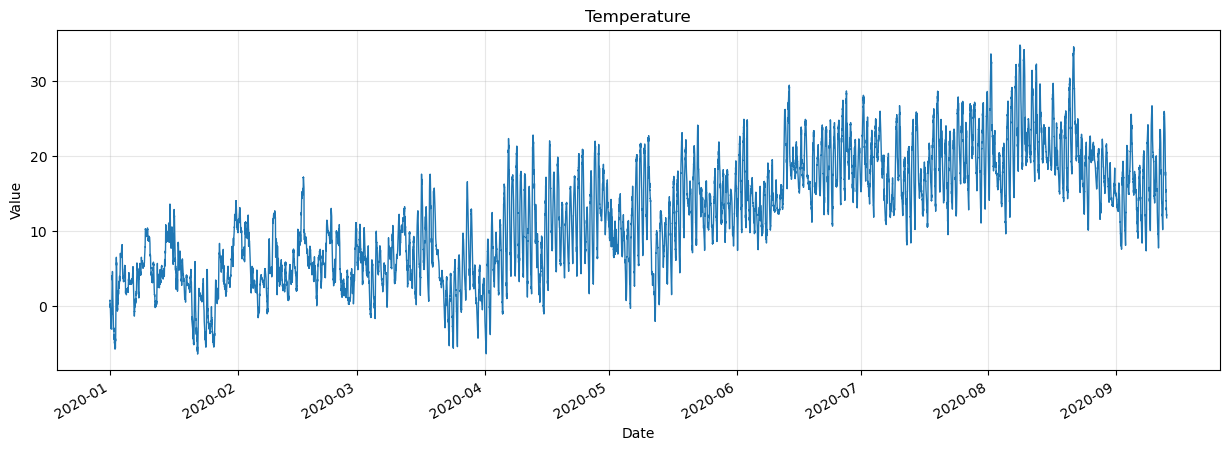

In [58]:
plot_series(eda_df, "T", "Temperature")